In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [4]:
data_train_path = r'C:\Users\vishn\OneDrive\Internship_Folder\Task - 2\Fruits_Vegetables\Fruits_Vegetables\train'
data_test_path = r'C:\Users\vishn\OneDrive\Internship_Folder\Task - 2\Fruits_Vegetables\Fruits_Vegetables\test'
data_val_path = r'C:\Users\vishn\OneDrive\Internship_Folder\Task - 2\Fruits_Vegetables\Fruits_Vegetables\validation'

In [5]:
img_width = 180
img_height = 180

In [6]:
# Data Preprocessing

In [7]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle = True,
    image_size = (img_width, img_height),
    batch_size = 32,
    validation_split = False)

Found 3115 files belonging to 36 classes.


In [8]:
data_cat = data_train.class_names

In [9]:
data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    image_size = (img_width, img_height),
    batch_size = 32,
    shuffle = False,
    validation_split = False)

Found 351 files belonging to 36 classes.


In [10]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    image_size = (img_width, img_height),
    batch_size = 32,
    shuffle = False,
    validation_split = False)

Found 360 files belonging to 36 classes.


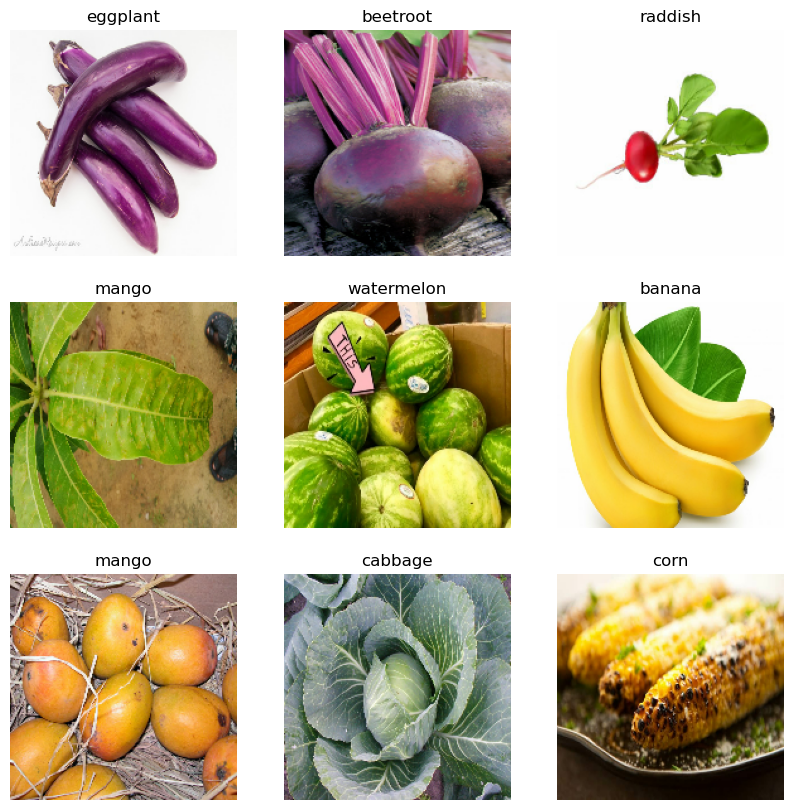

In [11]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [12]:
#Model Creation

In [13]:
from tensorflow.keras.models import Sequential

In [14]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [17]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(units = len(data_cat))
])

In [21]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
    metrics=['accuracy']
)

In [22]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 227ms/step - accuracy: 0.1223 - loss: 3.1620 - val_accuracy: 0.3875 - val_loss: 2.2058
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 187ms/step - accuracy: 0.3557 - loss: 2.2051 - val_accuracy: 0.6211 - val_loss: 1.3743
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 185ms/step - accuracy: 0.5291 - loss: 1.6200 - val_accuracy: 0.8148 - val_loss: 0.7350
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - accuracy: 0.7162 - loss: 0.9902 - val_accuracy: 0.8832 - val_loss: 0.4535
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.8594 - loss: 0.4838 - val_accuracy: 0.9459 - val_loss: 0.2804
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.9319 - loss: 0.2654 - val_accuracy: 0.9430 - val_loss: 0.2744
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 187ms/step - accuracy: 0.9650 - loss: 0.1635 - val_accuracy: 0.9544 - val_loss: 0.2304
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.9685 - loss: 0.1390 - val_accu

Text(0.5, 1.0, 'Loss')

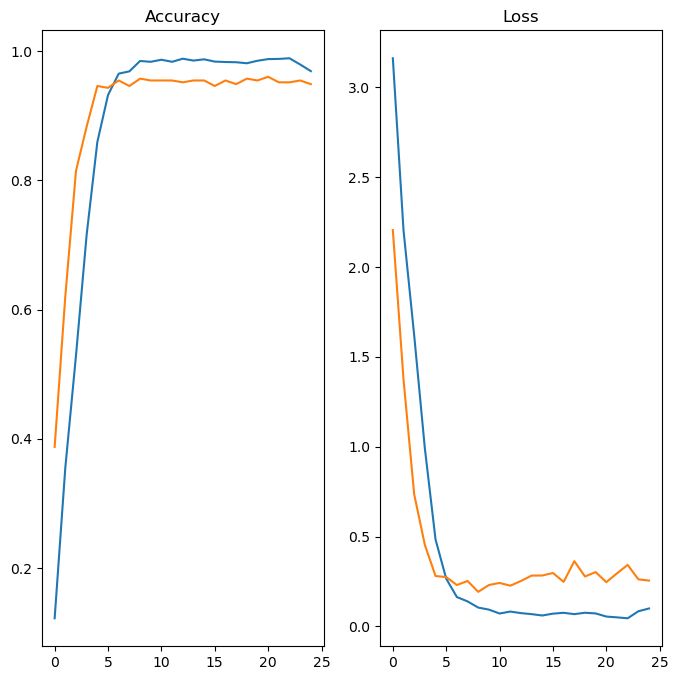

In [25]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range, history.history['accuracy'], label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy')
    
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label = 'Validation Loss')
plt.title('Loss')

In [ ]:
# Testing

In [30]:
image = r"C:\Users\vishn\OneDrive\Internship_Folder\Task - 2\apple.webp"
image = tf.keras.utils.load_img(image, target_size=(img_height, img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat = tf.expand_dims(img_arr, 0)

In [31]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [32]:
score = tf.nn.softmax(predict)

In [34]:
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)], np.max(score)*100))

Veg/Fruit in image is onion with accuracy of 84.63
